In [25]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data"


ACC_PATH  = DATA_DIR / "raw" / "test/log_20260209_125910.654" / "log_t0_acc_1.txt"
GYRO_PATH = DATA_DIR / "raw" / "test/log_20260209_125910.654" / "log_t0_gyro_1.txt"
ODO_PATH  = DATA_DIR / "raw" / "test/log_20260209_125910.654" / "log_t0_encoder_velocity.txt"

In [26]:
def read_log(path, cols, usecols=None):
    return pd.read_csv(
        path,
        comment="%",
        sep=r"\s+",
        header=None,
        names=cols,
        usecols=usecols,
        engine="python"
    ).dropna().sort_values(cols[0]).drop_duplicates(cols[0])

acc  = read_log(ACC_PATH,  ["t","ax","ay","az"])
gyro = read_log(GYRO_PATH, ["t","gx","gy","gz"])
odo = read_log(ODO_PATH, ["t","v1", "v2"], usecols=[0,1,2])
acc.head(), gyro.head(), odo.head()

(              t      ax      ay      az
 0  1.770638e+09 -0.1358  0.5183  0.8604
 1  1.770638e+09 -0.1314  0.5161  0.8628
 2  1.770638e+09 -0.1348  0.5171  0.8606
 3  1.770638e+09 -0.1344  0.5156  0.8731
 4  1.770638e+09 -0.1348  0.5166  0.8624,
               t      gx      gy      gz
 0  1.770638e+09 -3.4322 -9.8548 -1.6905
 1  1.770638e+09 -3.4617 -9.5496 -1.6984
 2  1.770638e+09 -3.5501 -9.5496 -1.7221
 3  1.770638e+09 -3.7449 -9.4581 -1.5848
 4  1.770638e+09 -3.4890 -9.5496 -1.8321,
               t   v1   v2
 0  1.770638e+09 -0.0  0.0
 1  1.770638e+09 -0.0  0.0
 2  1.770638e+09 -0.0  0.0
 3  1.770638e+09 -0.0  0.0
 4  1.770638e+09 -0.0  0.0)

In [27]:
t0 = min(acc["t"].iloc[0], gyro["t"].iloc[0], odo["t"].iloc[0])
acc["t_rel"]  = acc["t"]  - t0
gyro["t_rel"] = gyro["t"] - t0
odo["t_rel"]  = odo["t"]  - t0

acc.head(), gyro.head(), odo.head()

(              t      ax      ay      az   t_rel
 0  1.770638e+09 -0.1358  0.5183  0.8604  0.0002
 1  1.770638e+09 -0.1314  0.5161  0.8628  0.0123
 2  1.770638e+09 -0.1348  0.5171  0.8606  0.0245
 3  1.770638e+09 -0.1344  0.5156  0.8731  0.0364
 4  1.770638e+09 -0.1348  0.5166  0.8624  0.0484,
               t      gx      gy      gz   t_rel
 0  1.770638e+09 -3.4322 -9.8548 -1.6905  0.0000
 1  1.770638e+09 -3.4617 -9.5496 -1.6984  0.0112
 2  1.770638e+09 -3.5501 -9.5496 -1.7221  0.0233
 3  1.770638e+09 -3.7449 -9.4581 -1.5848  0.0353
 4  1.770638e+09 -3.4890 -9.5496 -1.8321  0.0472,
               t   v1   v2   t_rel
 0  1.770638e+09 -0.0  0.0  0.0001
 1  1.770638e+09 -0.0  0.0  0.0078
 2  1.770638e+09 -0.0  0.0  0.0157
 3  1.770638e+09 -0.0  0.0  0.0244
 4  1.770638e+09 -0.0  0.0  0.0320)

In [33]:
def qc(df, tcol="t_rel"):
    dt = df[tcol].diff().dropna().to_numpy()
    med = np.median(dt)
    return {
        "n": len(df),
        "duration_s": float(df[tcol].iloc[-1] - df[tcol].iloc[0]),
        "fs_med_hz": float(1.0 / med),
        "dt_med": float(med),
        "dt_p99": float(np.quantile(dt, 0.99)),
        "dt_max": float(dt.max()),
        "gap_ratio_dtmax_over_dtmed": float(dt.max() / med),
        "n_gaps_gt_5x_med": int(np.sum(dt > 5 * med)),
    }

print("ACC:", qc(acc, tcol="t_rel"))
print("GYRO:", qc(gyro, tcol="t_rel"))
print("ODO:", qc(odo, tcol="t_rel"))

ACC: {'n': 29643, 'duration_s': 355.70669984817505, 'fs_med_hz': 83.33275053643806, 'dt_med': 0.012000083923339844, 'dt_p99': 0.013000011444091797, 'dt_max': 0.017199993133544922, 'gap_ratio_dtmax_over_dtmed': 1.4333227370261463, 'n_gaps_gt_5x_med': 0}
GYRO: {'n': 29986, 'duration_s': 359.8210999965668, 'fs_med_hz': 83.33275053643806, 'dt_med': 0.012000083923339844, 'dt_p99': 0.013000011444091797, 'dt_max': 0.017000198364257812, 'gap_ratio_dtmax_over_dtmed': 1.4166732893586584, 'n_gaps_gt_5x_med': 0}
ODO: {'n': 45205, 'duration_s': 361.63370013237, 'fs_med_hz': 129.87069606143174, 'dt_med': 0.0076999664306640625, 'dt_p99': 0.008800029754638672, 'dt_max': 0.01380014419555664, 'gap_ratio_dtmax_over_dtmed': 1.792234332425068, 'n_gaps_gt_5x_med': 0}


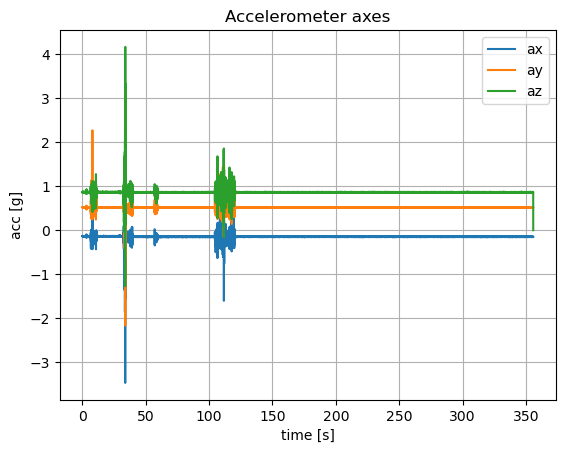

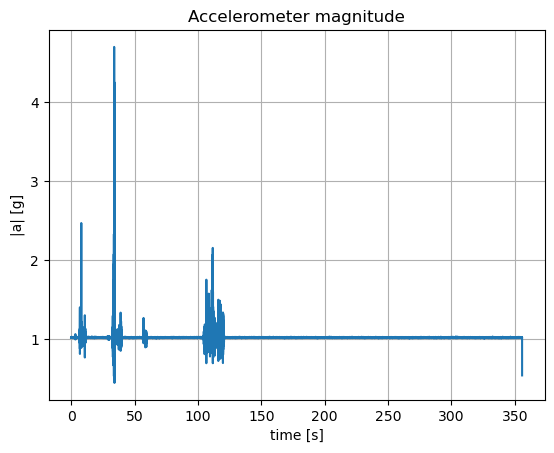

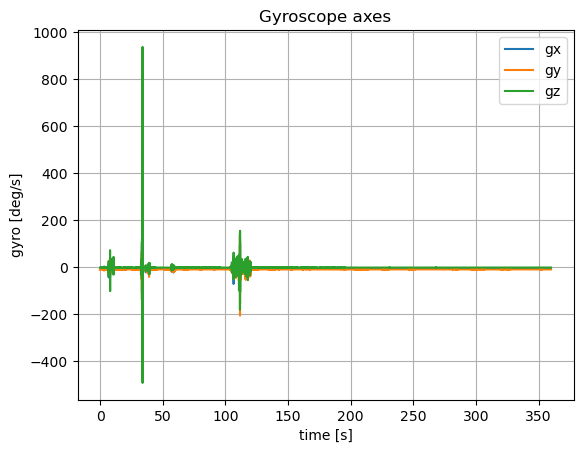

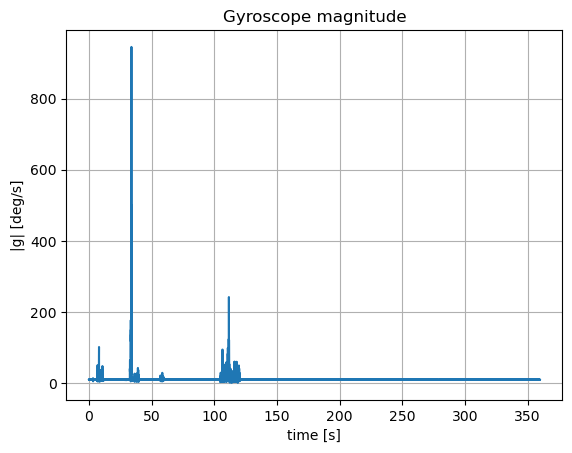

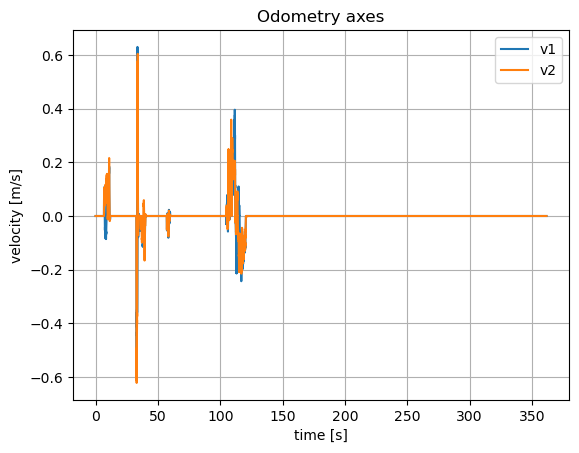

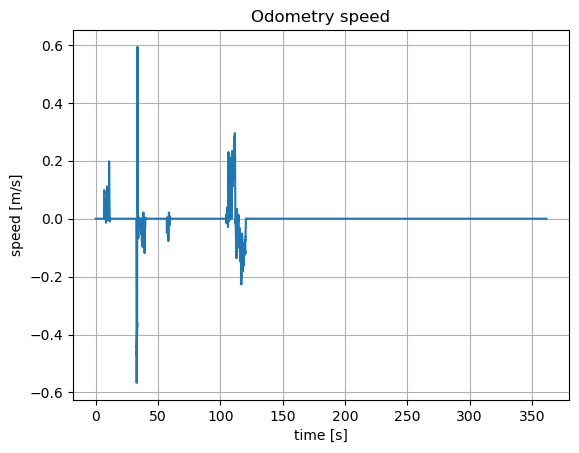

In [34]:
def plot_sanity(acc, gyro, odo, tcol="t_rel"):
    # -------- ACC axes --------
    plt.figure()
    plt.plot(acc[tcol], acc["ax"], label="ax")
    plt.plot(acc[tcol], acc["ay"], label="ay")
    plt.plot(acc[tcol], acc["az"], label="az")
    plt.xlabel("time [s]")
    plt.ylabel("acc [g]")
    plt.title("Accelerometer axes")
    plt.legend()
    plt.grid(True)

    # -------- ACC magnitude --------
    plt.figure()
    acc_mag = np.sqrt(acc["ax"]**2 + acc["ay"]**2 + acc["az"]**2)
    plt.plot(acc[tcol], acc_mag)
    plt.xlabel("time [s]")
    plt.ylabel("|a| [g]")
    plt.title("Accelerometer magnitude")
    plt.grid(True)

    # -------- GYRO axes --------
    plt.figure()
    plt.plot(gyro[tcol], gyro["gx"], label="gx")
    plt.plot(gyro[tcol], gyro["gy"], label="gy")
    plt.plot(gyro[tcol], gyro["gz"], label="gz")
    plt.xlabel("time [s]")
    plt.ylabel("gyro [deg/s]")
    plt.title("Gyroscope axes")
    plt.legend()
    plt.grid(True)

    # -------- GYRO magnitude --------
    plt.figure()
    gyro_mag = np.sqrt(gyro["gx"]**2 + gyro["gy"]**2 + gyro["gz"]**2)
    plt.plot(gyro[tcol], gyro_mag)
    plt.xlabel("time [s]")
    plt.ylabel("|g| [deg/s]")
    plt.title("Gyroscope magnitude")
    plt.grid(True)

    # -------- ODO axes --------
    plt.figure()
    plt.plot(odo[tcol], odo["v1"], label="v1")
    plt.plot(odo[tcol], odo["v2"], label="v2")
    plt.xlabel("time [s]")
    plt.ylabel("velocity [m/s]")
    plt.title("Odometry axes")
    plt.legend()
    plt.grid(True)

    # -------- ODO magnitude --------
    plt.figure()
    speed = 0.5*(odo["v1"] + odo["v2"])
    plt.plot(odo[tcol], speed)
    plt.xlabel("time [s]")
    plt.ylabel("speed [m/s]")
    plt.title("Odometry speed")
    plt.grid(True)
    

    plt.show()

plot_sanity(acc, gyro, odo)

In [ ]:
# “idle segment” bias checks
"""If it is idle at the start, estimate bias automatically from first N seconds (e.g., first 5 s) and print it."""

def bias_from_first_seconds(df, cols, tcol="t_rel", seconds=5):
    seg = df[df[tcol] <= seconds]
    return seg[cols].mean()

print("Gyro bias (first 5s):", bias_from_first_seconds(gyro, ["gx","gy","gz"]))
print("Acc mean (first 5s):", bias_from_first_seconds(acc, ["ax","ay","az"]))


In [37]:
acc_mag = np.sqrt(acc["ax"]**2+acc["ay"]**2+acc["az"]**2)
print("Acc |a| median (first 5s):", float(np.median(acc_mag[acc["t_rel"]<=5])))


Acc |a| median (first 5s): 1.0171793548829036


In [ ]:
# Time range checks
"""to know if sensors cover the same interval."""


def time_range(df, tcol="t_rel"):
    return float(df[tcol].min()), float(df[tcol].max())

print("Ranges (t_rel):",
      "ACC", time_range(acc),
      "GYRO", time_range(gyro),
      "ODO", time_range(odo))


Ranges (t_rel): ACC (0.00020003318786621094, 355.7068998813629) GYRO (0.0, 359.8210999965668) ODO (9.989738464355469e-05, 361.63380002975464)
